In [66]:
import scanpy as sc
import decoupler as dc
import pertpy as pt
sc.set_figure_params(figsize=(3, 3), frameon=False)
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import warnings
warnings.filterwarnings("ignore")

def make_pseudobulk(adata, celltype, ct_col="celltype_merged",
                    sample_cols=("mouse_id","genotype","age"),
                    layer="counts"):
    ad = adata[adata.obs[ct_col] == celltype].copy()
    if layer in ad.layers:
        X = ad.layers[layer]
    else:
        X = ad.X
    if sparse.issparse(X):
        X = X.tocsr()

    # define samples as unique combinations of sample_cols
    meta = ad.obs.loc[:, sample_cols].astype(str)
    meta["sample_id"] = meta.apply(lambda r: "_".join(r.values), axis=1)

    # aggregate counts by sample_id
    sample_ids = meta["sample_id"].values
    uniq = pd.Index(np.unique(sample_ids), name="sample_id")
    # map each cell to column index
    col_index = pd.Series(pd.Categorical(sample_ids, categories=uniq)).cat.codes.values

    # build counts: genes x samples
    n_genes = ad.n_vars
    n_samp  = len(uniq)
    M = np.zeros((n_genes, n_samp), dtype=np.int64)
    # fast aggregate with group-by via numpy
    for s in range(n_samp):
        idx = np.where(col_index == s)[0]
        if len(idx)==0: 
            continue
        Xi = X[idx]
        M[:, s] = Xi.sum(axis=0).A.ravel() if sparse.issparse(Xi) else Xi.sum(axis=0)

    # sample metadata frame
    smd = uniq.to_frame(index=False)
    # split back columns
    parts = smd["sample_id"].str.split("_", expand=True)
    for i, c in enumerate(sample_cols):
        smd[c] = parts[i].values
    smd["condition"] = smd["condition"].astype("category")
    # age: keep both categorical and numeric versions handy
    smd["age"] = smd["age"].astype(str)
    smd["age_num"] = pd.to_numeric(smd["age"], errors="coerce")

    # gene names
    genes = ad.var_names.to_list()

    return pd.DataFrame(M, index=genes, columns=smd["sample_id"]), smd.set_index("sample_id")

In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [3]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [4]:
adata = adata[adata.obs.cell_class.str.contains('ligo')]
adata = adata[~adata.obs.cell_class.str.contains('mic')]

In [13]:
adata

View of AnnData object with n_obs × n_vars = 184678 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [16]:
celltypes = adata.obs.cell_class.unique()
pb = {}   # dict: celltype -> (count_df, sample_metadata)
for ct in celltypes:
    pb[ct] = make_pseudobulk(adata, celltype=ct, ct_col = 'cell_class', sample_cols = ('sample_id', 'condition', 'age'))

In [44]:
# =======================
# mtDSB x Age DE analysis (pydeseq2, LRT-free)
# - Per-age simple effects: model vs control
# - Interaction proxy: delta-LFC between ages with z-test
# Requirements: pydeseq2, anndata, numpy, pandas
# Assumes: pb[ct] = (counts_df [genes x samples], meta_df indexed by sample_id with columns "condition","age")
# =======================

import os
import numpy as np
import pandas as pd
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
from statsmodels.stats.multitest import multipletests

# ---------- utilities ----------
def _align(counts_df, meta_df):
    if not counts_df.columns.equals(meta_df.index):
        common = counts_df.columns.intersection(meta_df.index)
        if len(common) == 0:
            raise ValueError("No overlapping sample IDs between counts_df.columns and meta_df.index")
        counts_df = counts_df.loc[:, common]
        meta_df   = meta_df.loc[common]
    return counts_df, meta_df

def _to_anndata(counts_df, meta_df):
    X = counts_df.T.astype(np.int64)  # samples x genes
    ad = AnnData(X=X.values)
    ad.obs_names = X.index.astype(str)
    ad.var_names = counts_df.index.astype(str)
    ad.obs = meta_df.copy()
    return ad

def _prep_condition(mdf, condition_col="condition", ref_condition="control"):
    mdf = mdf.copy()
    mdf[condition_col] = mdf[condition_col].astype(str).str.strip()
    uniq = list(pd.unique(mdf[condition_col]))
    # ensure ref present (case-insensitive rescue)
    if ref_condition not in uniq:
        m = [u for u in uniq if u.lower() == ref_condition.lower()]
        if not m:
            raise ValueError(f"Reference '{ref_condition}' not present. Found: {uniq}")
        ref_condition = m[0]
    mdf[condition_col] = pd.Categorical(
        mdf[condition_col],
        categories=[ref_condition] + [u for u in uniq if u != ref_condition],
        ordered=True
    )
    return mdf, ref_condition

def _detect_case(mdf, condition_col="condition", ref_condition="control"):
    cats = list(mdf[condition_col].cat.categories)
    case_levels = [c for c in cats if c != ref_condition]
    if len(case_levels) == 0:
        raise ValueError("No case level found (only control present).")
    # if multiple, pick the first deterministically
    return case_levels[0]

# ---------- DE pieces ----------
def simple_effect_at_age(counts_df, meta_df, age_value,
                         condition_col="condition", ref_condition="control",
                         n_cpus=8):
    """Run model vs control at a single age using a 1-factor DESeq2 model."""
    counts_df, meta_df = _align(counts_df, meta_df)

    mask = meta_df["age"].astype(str).str.strip() == str(age_value)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples at age={age_value}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()

    mdf, ref_condition = _prep_condition(mdf, condition_col=condition_col, ref_condition=ref_condition)
    case_label = _detect_case(mdf, condition_col=condition_col, ref_condition=ref_condition)

    ad = _to_anndata(cdf, mdf)
    dds = DeseqDataSet(
        adata=ad,
        design_factors=[condition_col],  # ~ condition
        refit_cooks=True,
        inference=DefaultInference(n_cpus=n_cpus),
    )
    dds.deseq2()

    st = DeseqStats(dds, contrast=[condition_col, case_label, ref_condition], inference=DefaultInference(n_cpus=n_cpus))
    st.summary()
    res = st.results_df.copy()
    res = res.rename(columns={
        "log2FoldChange": f"log2FC_{case_label}_vs_{ref_condition}",
        "lfcSE":          f"lfcSE_{case_label}_vs_{ref_condition}",
        "pvalue":         f"pvalue_{case_label}_vs_{ref_condition}",
        "padj":           f"padj_{case_label}_vs_{ref_condition}",
    })
    res.attrs = {"contrast": f"{case_label} vs {ref_condition} @ age {age_value}",
                 "age": str(age_value),
                 "case": case_label,
                 "ref": ref_condition}
    return res

def combine_delta_lfc(res_a, res_b):
    """
    Given two result DataFrames for the same genes (different ages),
    compute delta-LFC and a z-test using SEs: z = (lfc_b - lfc_a)/sqrt(se_b^2 + se_a^2)
    Returns a merged DataFrame with delta stats and FDR.
    """
    # infer column stems
    lfc_col_a = [c for c in res_a.columns if c.startswith("log2FC_")][0]
    se_col_a  = [c for c in res_a.columns if c.startswith("lfcSE_")][0]
    lfc_col_b = [c for c in res_b.columns if c.startswith("log2FC_")][0]
    se_col_b  = [c for c in res_b.columns if c.startswith("lfcSE_")][0]

    df = pd.DataFrame(index=res_a.index.union(res_b.index))
    df[lfc_col_a] = res_a[lfc_col_a]
    df[se_col_a]  = res_a[se_col_a]
    df[lfc_col_b] = res_b[lfc_col_b]
    df[se_col_b]  = res_b[se_col_b]

    # drop genes missing in either
    df = df.dropna(subset=[lfc_col_a, se_col_a, lfc_col_b, se_col_b]).copy()

    # delta and z
    df["delta_log2FC"] = df[lfc_col_b] - df[lfc_col_a]
    df["se_delta"] = np.sqrt(np.square(df[se_col_a]) + np.square(df[se_col_b]))
    # guard against zeros
    df["se_delta"] = df["se_delta"].replace(0, np.nan)
    df = df.dropna(subset=["se_delta"])
    df["z"] = df["delta_log2FC"] / df["se_delta"]
    # two-sided p from normal
    from scipy.stats import norm
    df["p_delta"] = 2 * (1 - norm.cdf(np.abs(df["z"])))
    df["q_delta"] = multipletests(df["p_delta"], method="fdr_bh")[1]
    return df

# ---------- main runner ----------
def run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False):
    """
    pb: dict like {"Oligodendrocyte": (counts_df, meta_df), ...}
    For each cell type:
      - compute per-age simple effects (model vs control) for all ages present
      - compute pairwise delta-LFC interaction proxy for all age pairs
    Returns: results dict per cell type
    """
    if save_csv and outdir:
        os.makedirs(outdir, exist_ok=True)

    results = {}
    for ct, (counts_df, meta_df) in pb.items():
        # discover ages (preserve observed order)
        ages = list(pd.unique(meta_df["age"].astype(str).str.strip()))
        per_age = {}
        # run simple effects
        for a in ages:
            try:
                res = simple_effect_at_age(counts_df, meta_df, a,
                                           condition_col=condition_col,
                                           ref_condition="control",
                                           n_cpus=n_cpus)
                per_age[a] = res
                if save_csv and outdir:
                    res.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_simple_effect_age_{a}.csv"))
            except Exception as e:
                per_age[a] = None
                print(f"[{ct}] simple-effect failed at age={a}: {e}")

        # delta-LFC interaction proxy (all unique pairs)
        deltas = {}
        age_pairs = []
        for i in range(len(ages)):
            for j in range(i+1, len(ages)):
                a, b = ages[i], ages[j]
                if per_age.get(a) is None or per_age.get(b) is None:
                    continue
                dtab = combine_delta_lfc(per_age[a], per_age[b])
                dtab.attrs = {"age_A": a, "age_B": b,
                              "note": "delta_log2FC = LFC(age_B) - LFC(age_A)"}
                deltas[(a,b)] = dtab
                age_pairs.append((a,b))
                if save_csv and outdir:
                    dtab.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_deltaLFC_{a}_vs_{b}.csv"))

        results[ct] = {
            "simple_effects": per_age,   # dict age -> DE table
            "deltas": deltas,            # dict (ageA,ageB) -> delta table with q_delta
            "ages": ages,
            "age_pairs": age_pairs
        }

    return results



In [45]:
# ====== EXAMPLE CALL ======
# results = run_all(pb, condition_col="condition", outdir="./deseq_mtDSB_results", n_cpus=8, save_csv=True)
results = run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False)

# Access:
# results["Oligodendrocyte"]["simple_effects"]["21"].head()
# results["Oligodendrocyte"]["deltas"][("21","60")].sort_values("q_delta").head()

/tmp/ipykernel_10310/1816131803.py:77: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.

/tmp/ipykernel_10310/1816131803.py:77: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  1182.305468        0.208897  0.145926  1.431532  0.152278   
9630013A20Rik  2105.138848        0.365869  0.269775  1.356202  0.175035   
A1cf              3.589109       -1.841412  1.147881 -1.604184  0.108673   
A2m             342.022173        1.038859  0.294281  3.530157  0.000415   
Aatf           1446.297850        0.127922  0.164387  0.778176  0.436465   
...                    ...             ...       ...       ...       ...   
Zswim9          235.080892       -0.150295  0.196322 -0.765556  0.443941   
Zup1            275.153589        0.054504  0.180005  0.302790  0.762050   
Zyx             691.700478        0.153414  0.237869  0.644950  0.518960   
Zzef1          1178.695495       -0.113610  0.130920 -0.867786  0.385511   
a                 2.834891       -1.652620  1.408721 -1.173135  0.240742   

                   pad

... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.23 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.12 seconds.

/tmp/ipykernel_10310/1816131803.py:77: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


...

... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.

/tmp/ipykernel_10310/1816131803.py:77: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  354.806497       -0.032777  0.130757 -0.250675  0.802065   
9630013A20Rik  188.273415        0.175163  0.200713  0.872706  0.382823   
A1cf             0.297327        1.541976  3.726999  0.413731  0.679071   
A2m             35.509465        1.063168  0.410053  2.592760  0.009521   
Aatf           241.691633       -0.001442  0.144042 -0.010014  0.992010   
...                   ...             ...       ...       ...       ...   
Zswim9          52.405484        0.004298  0.268525  0.016004  0.987231   
Zup1            71.941261       -0.184185  0.232327 -0.792782  0.427905   
Zyx            136.928137       -0.047332  0.175527 -0.269659  0.787423   
Zzef1          251.462344        0.001120  0.140842  0.007954  0.993654   
a                0.344825       -0.278215  3.428098 -0.081157  0.935317   

                   padj  
2610035D

... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.19 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



Log2 fold change & Wald test p-value: condition mtDSB vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  313.107001        0.144041  0.128263  1.123014  0.261432   
9630013A20Rik  179.594990        0.391925  0.166861  2.348805  0.018834   
A1cf             0.357486       -1.937256  3.558575 -0.544391  0.586173   
A2m             21.687597        0.604579  0.468622  1.290121  0.197008   
Aatf           278.509710       -0.131626  0.132423 -0.993981  0.320232   
...                   ...             ...       ...       ...       ...   
Zswim9          54.851815        0.024384  0.274102  0.088961  0.929113   
Zup1            77.311811        0.313902  0.225088  1.394571  0.163145   
Zyx            134.898023       -0.175531  0.183089 -0.958719  0.337700   
Zzef1          276.506830        0.158756  0.136250  1.165184  0.243945   
a                0.131617        0.969656  4.427862  0.218990  0.826658   

                   padj  
2610035D

Running Wald tests...
... done in 0.12 seconds.



In [50]:
results['Mature oligodendrocytes']["deltas"]

{('60',
  '21'):                log2FC_mtDSB_vs_control  lfcSE_mtDSB_vs_control  delta_log2FC  \
 2610035D17Rik                 0.214450                0.185925           0.0   
 9630013A20Rik                -0.193845                0.247698           0.0   
 A1cf                          1.498837                1.289822           0.0   
 A2m                           0.061922                0.356558           0.0   
 Aatf                          0.102172                0.179104           0.0   
 ...                                ...                     ...           ...   
 Zswim9                       -0.073389                0.176310           0.0   
 Zup1                          0.121529                0.165756           0.0   
 Zyx                          -0.123781                0.131590           0.0   
 Zzef1                         0.101737                0.133969           0.0   
 a                             1.713283                1.805735           0.0   
 
          

In [52]:
results['Mature oligodendrocytes']["deltas"][('60','21')].sort_values("q_delta").head()

,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,delta_log2FC,se_delta,z,p_delta,q_delta
2610035D17Rik,0.214450,0.185925,0.0,0.262938,0.0,1.0,1.0
Pdgfa,-0.099489,0.155713,0.0,0.220211,0.0,1.0,1.0
Pde8b,-0.154143,0.186454,0.0,0.263686,0.0,1.0,1.0
Pde8a,-0.183613,0.132537,0.0,0.187436,0.0,1.0,1.0
Pde7b,0.164249,0.214376,0.0,0.303173,0.0,1.0,1.0


In [54]:
res21 = results["Mature oligodendrocytes"]["simple_effects"]["21"]
res60 = results["Mature oligodendrocytes"]["simple_effects"]["60"]

In [58]:
res21.sort_values(by = 'log2FC_mtDSB_vs_control', ascending=False).head(50)

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control
Hcrt,256.263933,4.197942,1.337587,3.138444,1.698476e-03,0.434529
Gdf15,93.889208,4.012649,2.010511,1.995836,NaN,NaN
Trib3,306.833391,3.890990,1.784528,2.180403,NaN,NaN
Cd40,141.795260,3.860621,1.664869,2.318874,NaN,NaN
Fut1,2.601138,3.814487,1.986977,1.919744,5.489019e-02,0.999912
Adad1,0.865285,3.283369,2.859400,1.148272,2.508563e-01,0.999912
Slco1a1,0.865285,3.283369,2.859400,1.148272,2.508563e-01,0.999912
Cst7,16.769032,3.107308,0.893445,3.477895,5.053679e-04,0.214487
Hesx1,0.710920,2.995482,3.450443,0.868144,3.853154e-01,0.999912
Gcg,0.682778,2.945126,3.038511,0.969266,3.324124e-01,0.999912


In [60]:
print(res60.sort_values(by = 'log2FC_mtDSB_vs_control', ascending=False).head(10))

            baseMean  log2FC_mtDSB_vs_control  lfcSE_mtDSB_vs_control  \
Trib3     398.099298                 5.097241                1.446544   
Cd40      333.356408                 4.856463                1.522588   
Gdf15     107.993546                 4.729959                1.449586   
Cst7       82.168249                 4.116523                1.251327   
Hoxb5      16.962921                 3.803151                1.854352   
Cdkn1a    628.630468                 3.785308                1.185932   
Il13ra2     2.160349                 3.307559                1.877179   
Scimp       1.965076                 3.230243                1.917647   
Gpnmb     165.426357                 3.206350                0.869122   
Serpine1   34.140351                 3.166256                0.721650   

              stat  pvalue_mtDSB_vs_control  padj_mtDSB_vs_control  
Trib3     3.523738                 0.000426               0.079551  
Cd40      3.189611                 0.001425               

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lfc_across_ages(results, ct, gene):
    # ensure numeric ordering of ages (e.g. 21 < 60)
    ages = results[ct]["ages"]
    # try to sort numerically, fallback to lexicographic
    try:
        ages = sorted(ages, key=lambda x: float(x))
    except Exception:
        ages = sorted(ages)

    lfc, padj = [], []

    for a in ages:
        res = results[ct]["simple_effects"].get(a)
        if res is not None and gene in res.index:
            # grab first column starting with "log2FC_" and "padj_"
            lfc_col = next(c for c in res.columns if c.startswith("log2FC_"))
            padj_col = next(c for c in res.columns if c.startswith("padj_"))
            lfc.append(res.loc[gene, lfc_col])
            padj.append(res.loc[gene, padj_col])
        else:
            lfc.append(np.nan)
            padj.append(np.nan)

    plt.figure(figsize=(5,4))
    plt.plot(ages, lfc, marker="o", color="black", lw=1)
    for i, a in enumerate(ages):
        if not np.isnan(lfc[i]):
            sig = padj[i] < 0.05 if not np.isnan(padj[i]) else False
            plt.scatter(a, lfc[i], c="red" if sig else "grey", s=60, zorder=3)
    plt.axhline(0, ls="--", c="k", lw=0.8)
    plt.title(f"{ct}: {gene} (mtDSB vs control)")
    plt.ylabel("log2FC")
    plt.xlabel("Age (weeks)")
    plt.tight_layout()
    plt.show()

2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


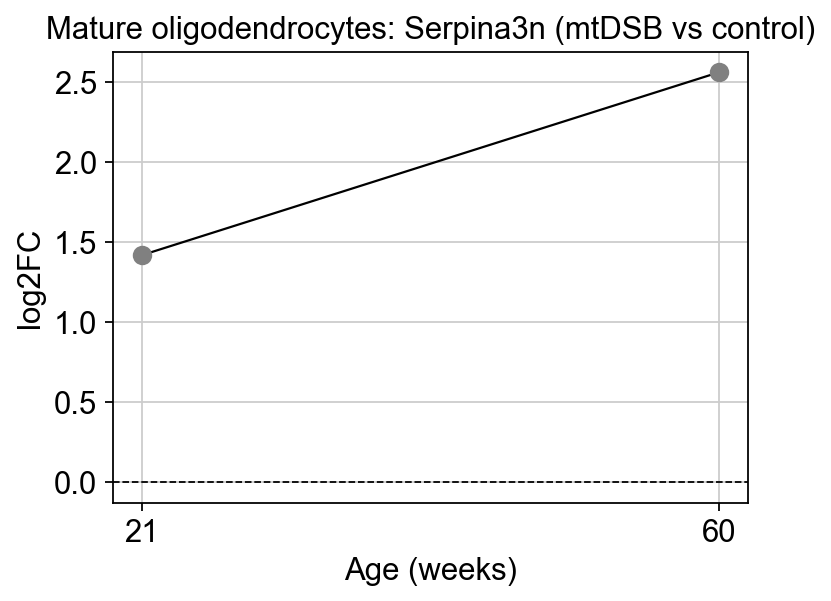

2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


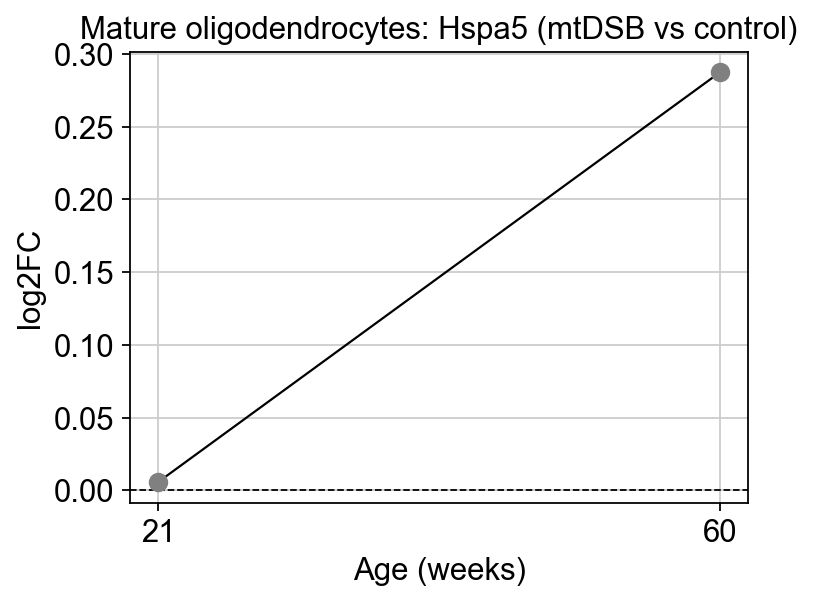

2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


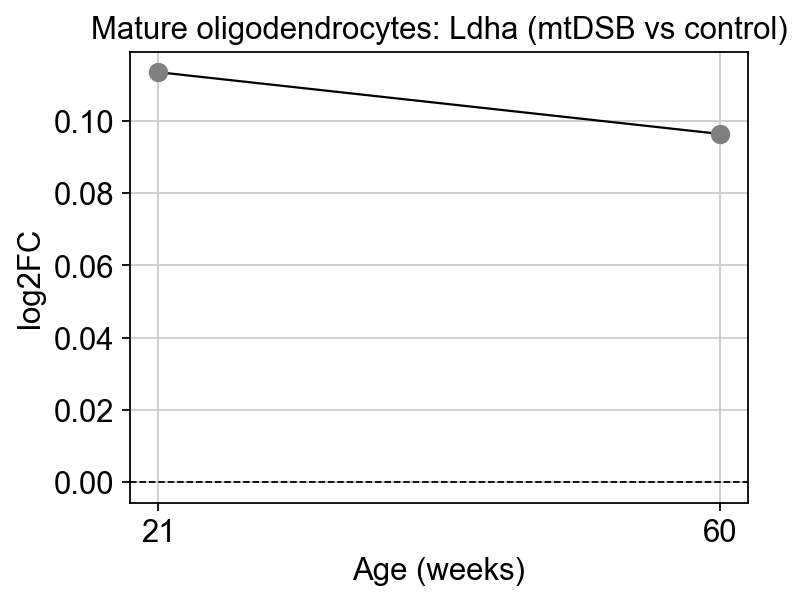

2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


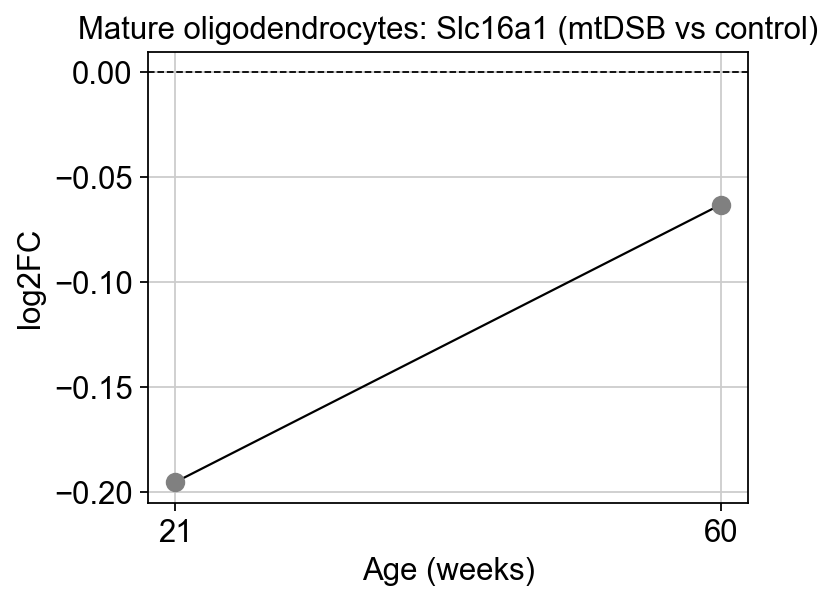

2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


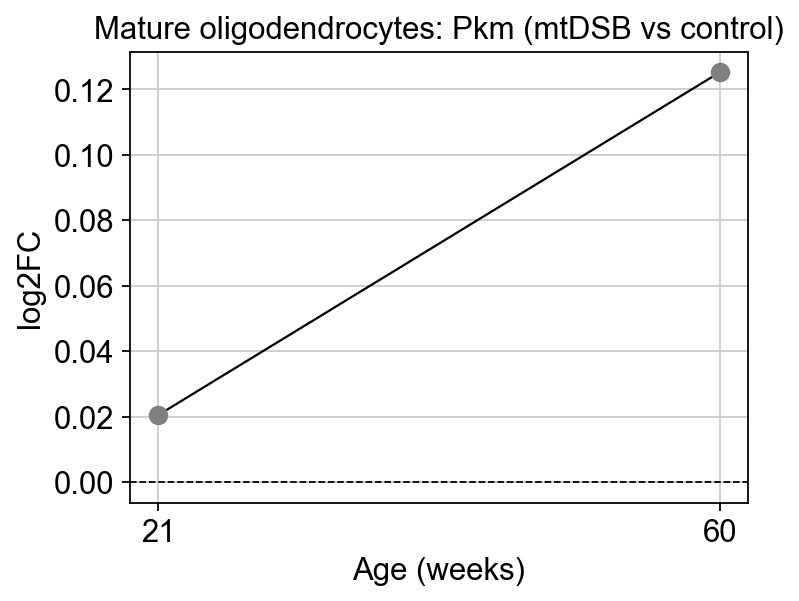

2025-10-08 13:42:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:56 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


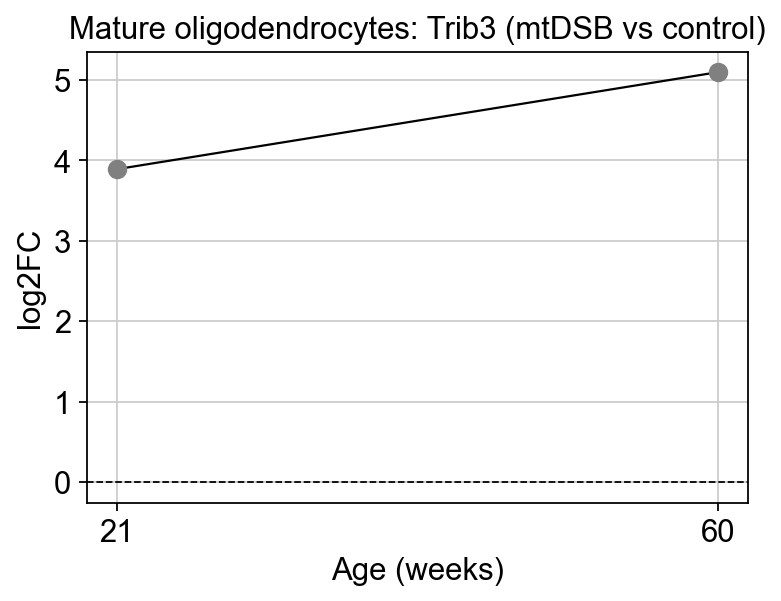

In [79]:
plot_lfc_across_ages(results, "Mature oligodendrocytes", "Serpina3n")
plot_lfc_across_ages(results, "Mature oligodendrocytes", "Hspa5")
plot_lfc_across_ages(results, "Mature oligodendrocytes", "Ldha")
plot_lfc_across_ages(results, "Mature oligodendrocytes", "Slc16a1")
plot_lfc_across_ages(results, "Mature oligodendrocytes", "Pkm")
plot_lfc_across_ages(results, "Mature oligodendrocytes", "Trib3")


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

def plot_expression_by_condition(pb, ct, gene, norm=True, suppress_warnings=True):
    """
    Plot mean expression (pseudobulk counts) across ages for each condition.
    pb: dict like pb[ct] = (counts_df, meta_df)
    gene: gene symbol in counts_df.index
    norm: if True, CPM-normalize each sample before averaging
    """
    if suppress_warnings:
        warnings.filterwarnings("ignore")

    counts_df, meta_df = pb[ct]
    if gene not in counts_df.index:
        print(f"{gene} not found in counts_df for {ct}")
        return

    df = counts_df.loc[gene].to_frame("counts")
    df["sample"] = df.index
    df["age"] = meta_df.loc[df.index, "age"].astype(str).str.strip()
    df["condition"] = meta_df.loc[df.index, "condition"].astype(str).str.strip()

    # normalize per sample library size if desired
    if norm:
        lib = counts_df.sum(axis=0)
        df["cpm"] = (df["counts"] / lib[df.index].values) * 1e6
        val_col = "cpm"
    else:
        val_col = "counts"

    mean_df = (
        df.groupby(["condition", "age"], observed=True)[val_col]
          .agg(["mean", "sem"])
          .reset_index()
    )

    try:
        ages_sorted = sorted(mean_df["age"].unique(), key=lambda x: float(x))
    except Exception:
        ages_sorted = sorted(mean_df["age"].unique())

    plt.figure(figsize=(5, 4))
    for cond, sub in mean_df.groupby("condition"):
        sub = sub.set_index("age").loc[ages_sorted].reset_index()
        plt.errorbar(sub["age"], sub["mean"], yerr=sub["sem"],
                     marker="o", capsize=3, label=cond)
    plt.title(f"{ct}: {gene} expression")
    plt.ylabel("Mean CPM" if norm else "Counts")
    plt.xlabel("Age (weeks)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

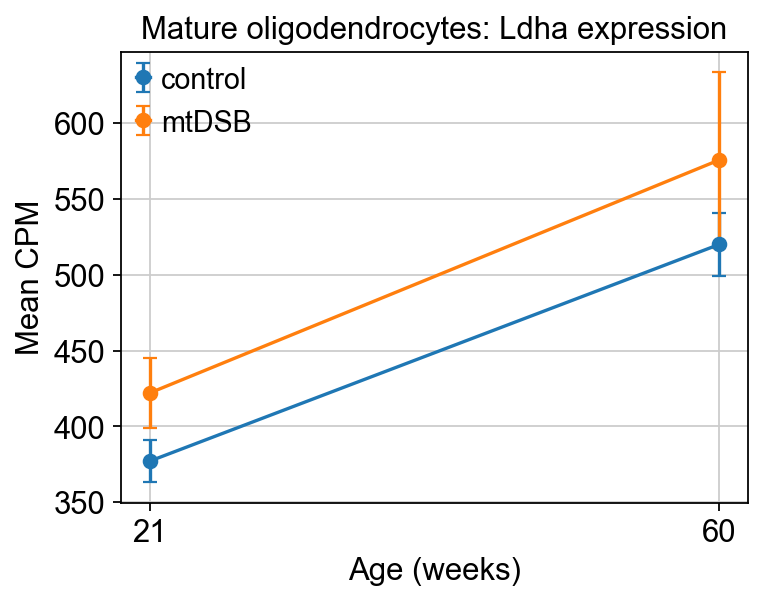

2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

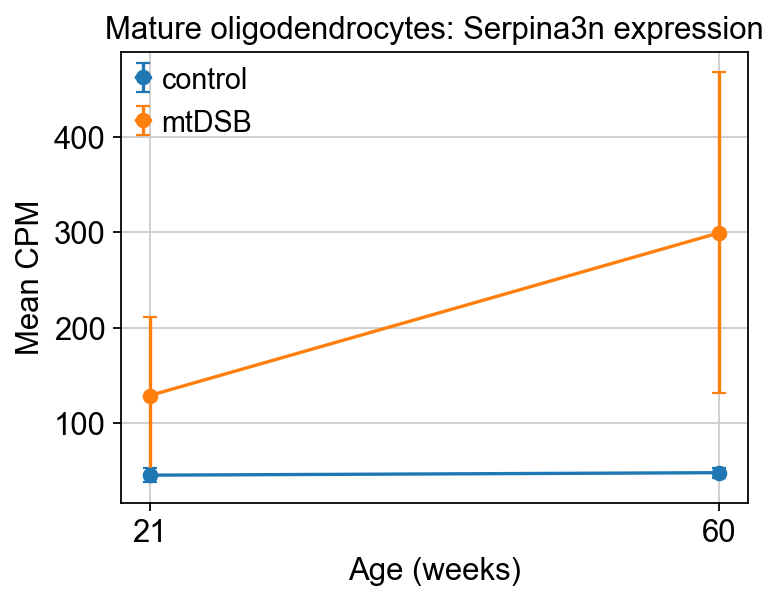

2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

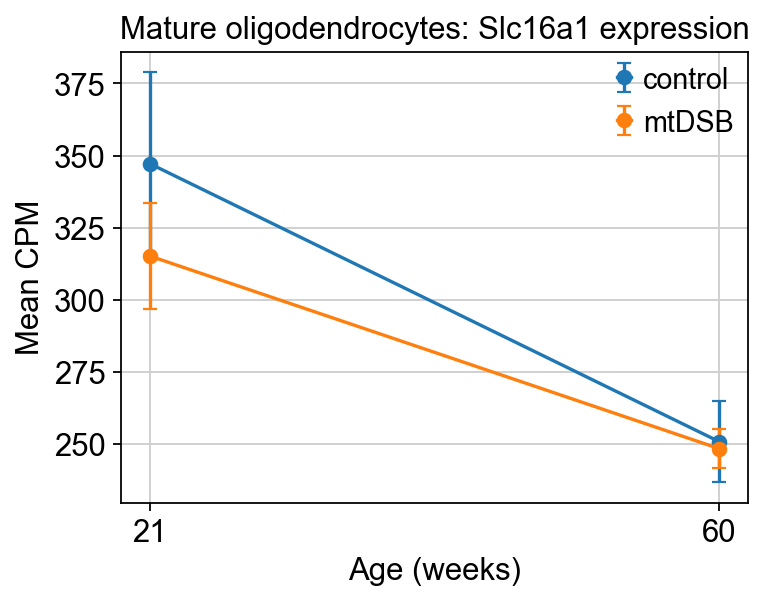

2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-08 13:42:25 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

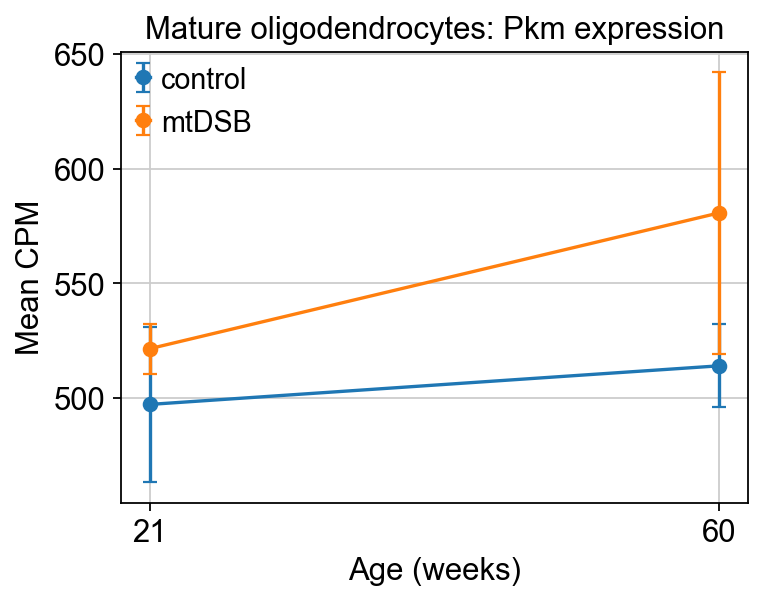

In [77]:
plot_expression_by_condition(pb, "Mature oligodendrocytes", "Ldha")
plot_expression_by_condition(pb, "Mature oligodendrocytes", "Serpina3n")
plot_expression_by_condition(pb, "Mature oligodendrocytes", "Slc16a1")
plot_expression_by_condition(pb, "Mature oligodendrocytes", "Pkm")